In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

#### Chargement des données

Ce jeu de données contient des informations sur des clients d’un opérateur télécom, utilisées pour analyser les facteurs influençant le départ des clients


In [2]:
data=pd.read_csv('../data/raw/churn.csv')

In [3]:
data.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2043,6557-BZXLQ,Male,1,No,No,16,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Electronic check,69.65,1043.3,No
3785,8337-UPOAQ,Male,1,Yes,No,10,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,89.80,914.3,Yes
4463,4603-JANFB,Male,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.85,69.85,Yes
503,7803-XOCCZ,Female,0,Yes,Yes,52,Yes,No,Fiber optic,Yes,...,Yes,Yes,No,No,Month-to-month,Yes,Bank transfer (automatic),84.05,4326.8,No
479,6227-HWPWX,Female,0,No,Yes,15,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),69.00,994.8,Yes


In [4]:
data.shape

(7043, 21)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
data.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Description générale du dataset 
Le jeu de données Telco Customer Churn contient des informations sur 7 043 clients d’une entreprise de télécommunication.
Chaque ligne représente un client, et les 21 colonnes décrivent ses caractéristiques démographiques, ses services souscrits, et ses informations de facturation.

les differrents colonnes que nous avonst sont:


## Description du jeu de données — Projet de déclassification (Churn)

Le jeu de données **Telco Customer Churn** contient des informations sur **7 043 clients** d’une entreprise de télécommunication.  
Chaque ligne représente **un client**, avec des informations sur son profil, les services qu’il utilise et ses données de facturation.

##  Objectif du projet
L’objectif de ce projet est de **prédire si un client va résilier son contrat** (`Churn`).  
Autrement dit, il s’agit de déterminer, à partir des caractéristiques d’un client, **le risque qu’il quitte l’entreprise**.  
Ce type de projet aide à **anticiper les départs** et à **améliorer la fidélisation des clients**.

##  Description des variables

| Nom original | Description |
|---------------|-------------|
| `customerID` | Identifiant unique du client |
| `gender` | Sexe du client (Male / Female) |
| `SeniorCitizen` | Indique si le client est une personne âgée (1 = oui, 0 = non) |
| `Partner` | Indique si le client vit en couple (Yes / No) |
| `Dependents` | Indique si le client a des personnes à charge (Yes / No) |
| `tenure` | Ancienneté du client (en mois) |
| `PhoneService` | Le client a-t-il un service téléphonique ? (Yes / No) |
| `MultipleLines` | Le client a-t-il plusieurs lignes téléphoniques ? |
| `InternetService` | Type de service Internet (DSL / Fiber optic / None) |
| `OnlineSecurity` | Option de sécurité Internet souscrite (Yes / No) |
| `OnlineBackup` | Option de sauvegarde en ligne souscrite (Yes / No) |
| `DeviceProtection` | Protection des appareils activée (Yes / No) |
| `TechSupport` | Service de support technique disponible (Yes / No) |
| `StreamingTV` | Le client regarde-t-il la TV en streaming ? |
| `StreamingMovies` | Le client regarde-t-il des films en streaming ? |
| `Contract` | Type de contrat (Month-to-month / One year / Two year) |
| `PaperlessBilling` | Facturation papier ou électronique (Yes / No) |
| `PaymentMethod` | Méthode de paiement utilisée |
| `MonthlyCharges` | Montant facturé chaque mois |
| `TotalCharges` | Montant total payé depuis le début du contrat |
| `Churn` | Variable cible : le client a-t-il résilié son abonnement ? (Yes / No) |

## Remarques
- Le jeu de données contient **21 variables** et **7 043 observations**.  
- La colonne cible pour la prédiction est **`Churn`**.  
- Certaines colonnes, comme `TotalCharges`, devront être converties en valeurs numériques avant analyse.





In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
data.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1015,3863-IUBJR,Male,0,Yes,Yes,12,Yes,No,DSL,No,...,No,No,No,Yes,One year,No,Credit card (automatic),53.65,696.35,Yes
842,1038-ZAGBI,Female,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),19.80,229.6,Yes
6036,8008-ESFLK,Female,0,Yes,No,53,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,110.50,5835.5,No
6888,3191-CSNMG,Female,0,Yes,Yes,3,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,80.70,239.45,No
85,4445-ZJNMU,Male,0,No,No,9,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),99.30,918.75,No


In [10]:
##Conversion de la colonne TotalCharges en numérique
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [11]:
##suppression de la variable customerID
data.drop('customerID', axis=1, inplace=True)

In [12]:
# 🔹 Renommage des colonnes du DataFrame 'data'

data = data.rename(columns={
    "customerID": "id_client",
    "gender": "sexe",
    "SeniorCitizen": "senior",
    "Partner": "en_couple",
    "Dependents": "ayant_personnes_a_charge",
    "tenure": "anciennete_mois",
    "PhoneService": "service_telephone",
    "MultipleLines": "lignes_multiples",
    "InternetService": "type_internet",
    "OnlineSecurity": "securite_en_ligne",
    "OnlineBackup": "sauvegarde_en_ligne",
    "DeviceProtection": "protection_appareils",
    "TechSupport": "support_technique",
    "StreamingTV": "tv_en_streaming",
    "StreamingMovies": "films_en_streaming",
    "Contract": "type_contrat",
    "PaperlessBilling": "facturation_numerique",
    "PaymentMethod": "methode_paiement",
    "MonthlyCharges": "frais_mensuels",
    "TotalCharges": "frais_totaux",
    "Churn": "resiliation"
})

# ✅ Vérification du renommage
print("✅ Colonnes renommées :")
print(data.columns.tolist())


✅ Colonnes renommées :
['sexe', 'senior', 'en_couple', 'ayant_personnes_a_charge', 'anciennete_mois', 'service_telephone', 'lignes_multiples', 'type_internet', 'securite_en_ligne', 'sauvegarde_en_ligne', 'protection_appareils', 'support_technique', 'tv_en_streaming', 'films_en_streaming', 'type_contrat', 'facturation_numerique', 'methode_paiement', 'frais_mensuels', 'frais_totaux', 'resiliation']


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sexe                      7043 non-null   object 
 1   senior                    7043 non-null   int64  
 2   en_couple                 7043 non-null   object 
 3   ayant_personnes_a_charge  7043 non-null   object 
 4   anciennete_mois           7043 non-null   int64  
 5   service_telephone         7043 non-null   object 
 6   lignes_multiples          7043 non-null   object 
 7   type_internet             7043 non-null   object 
 8   securite_en_ligne         7043 non-null   object 
 9   sauvegarde_en_ligne       7043 non-null   object 
 10  protection_appareils      7043 non-null   object 
 11  support_technique         7043 non-null   object 
 12  tv_en_streaming           7043 non-null   object 
 13  films_en_streaming        7043 non-null   object 
 14  type_con

In [16]:
# 🔹 Identification automatique des variables catégorielles
cat_cols = data.select_dtypes(include=['object']).columns

# 🔹 Conversion de toutes les colonnes 'object' en 'category'
data[cat_cols] = data[cat_cols].astype('category')

data["senior"] = data["senior"].astype("category")


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   sexe                      7043 non-null   category
 1   senior                    7043 non-null   category
 2   en_couple                 7043 non-null   category
 3   ayant_personnes_a_charge  7043 non-null   category
 4   anciennete_mois           7043 non-null   int64   
 5   service_telephone         7043 non-null   category
 6   lignes_multiples          7043 non-null   category
 7   type_internet             7043 non-null   category
 8   securite_en_ligne         7043 non-null   category
 9   sauvegarde_en_ligne       7043 non-null   category
 10  protection_appareils      7043 non-null   category
 11  support_technique         7043 non-null   category
 12  tv_en_streaming           7043 non-null   category
 13  films_en_streaming        7043 non-null   catego

In [18]:
data.sample(5)

,sexe,senior,en_couple,ayant_personnes_a_charge,anciennete_mois,service_telephone,lignes_multiples,type_internet,securite_en_ligne,sauvegarde_en_ligne,protection_appareils,support_technique,tv_en_streaming,films_en_streaming,type_contrat,facturation_numerique,methode_paiement,frais_mensuels,frais_totaux,resiliation
992,Female,0,Yes,Yes,22,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),25.25,555.40,No
557,Male,0,No,No,38,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,One year,No,Mailed check,70.60,2708.20,No
3636,Female,0,No,Yes,11,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),19.70,216.20,No
665,Female,0,No,No,3,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Mailed check,74.75,238.10,No
4585,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.05,85.05,Yes


In [19]:
### changé les modalité de la variable senior de et 1 par senior et 0 par non senior
data['senior'] = data['senior'].cat.rename_categories({0: 'non_senior', 1: 'senior'})

In [20]:
data['anciennete_mois'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

### STATISTIQUE DESCRIPTIVE

### 1.Univariée

In [26]:
##Variables quantitatives
col_num = ['anciennete_mois', 'frais_mensuels', 'frais_totaux']
##Variables qualitatives
col_cat = data.select_dtypes(include=['category']).columns.tolist()

In [32]:


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set(style="whitegrid", palette="crest", font_scale=1.1)

def analyse_quantitative(df, cols, show_return=False):
    """
    Analyse complète des variables quantitatives :
    - Statistiques descriptives (affichage stylé)
    - Histogramme + densité
    - Boxplot
    """

    summary_data = []

    # --- Résumé statistique ---
    for col in cols:
        series = pd.to_numeric(df[col], errors="coerce").dropna()
        summary_data.append({
            "Variable": col,
            "Nb valeurs": series.count(),
            "Valeurs manquantes": df[col].isna().sum(),
            "Moyenne": series.mean(),
            "Médiane": series.median(),
            "Écart-type": series.std(),
            "Min": series.min(),
            "25%": series.quantile(0.25),
            "75%": series.quantile(0.75),
            "Max": series.max(),
            "Asymétrie (skew)": series.skew(),
            "Aplatissement (kurtosis)": series.kurt()
        })

    summary_df = pd.DataFrame(summary_data)

    # ✅ Affiche uniquement le joli tableau stylé
    display(summary_df.style.background_gradient(cmap="Blues").format(precision=2))

    # --- Visualisations ---
    for col in cols:
        data_col = pd.to_numeric(df[col], errors="coerce").dropna()
        if data_col.empty:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(f"Analyse univariée — {col}", fontsize=15, fontweight='bold')

        # Histogramme + densité
        sns.histplot(data_col, kde=True, ax=axes[0], bins=30)
        axes[0].set_title(f"Distribution de {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Fréquence")

        # Boxplot
        sns.boxplot(x=data_col, ax=axes[1])
        axes[1].set_title(f"Boxplot de {col}")
        axes[1].set_xlabel(col)

        plt.tight_layout(pad=2.5)
        plt.show()

    # 🔇 Ne pas afficher automatiquement le tableau brut
    if show_return:
        return summary_df




,Variable,Nb valeurs,Valeurs manquantes,Moyenne,Médiane,Écart-type,Min,25%,75%,Max,Asymétrie (skew),Aplatissement (kurtosis)
0,anciennete_mois,7043,0,32.37,29.00,24.56,0.00,9.00,55.00,72.00,0.24,-1.39
1,frais_mensuels,7043,0,64.76,70.35,30.09,18.25,35.50,89.85,118.75,-0.22,-1.26
2,frais_totaux,7032,11,2283.30,1397.47,2266.77,18.80,401.45,3794.74,8684.80,0.96,-0.23


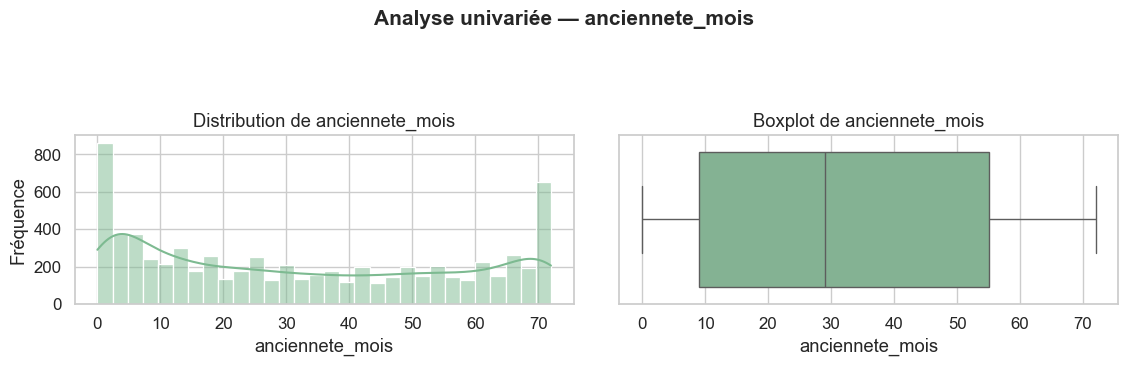

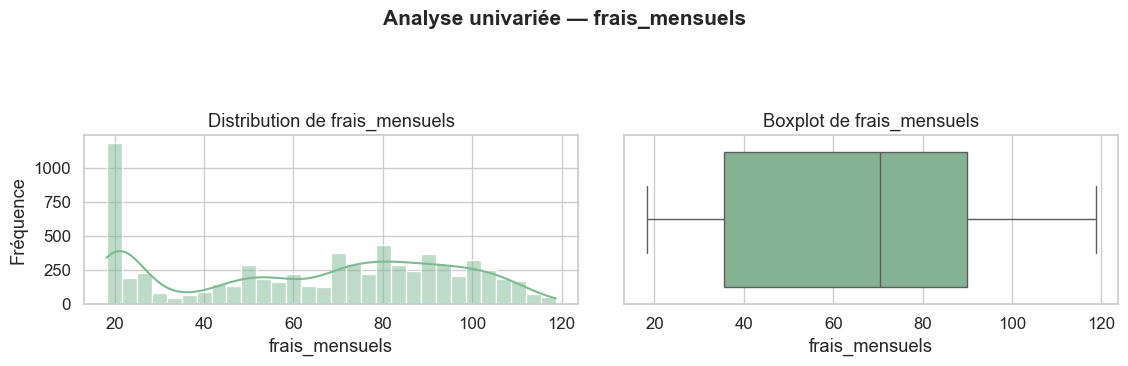

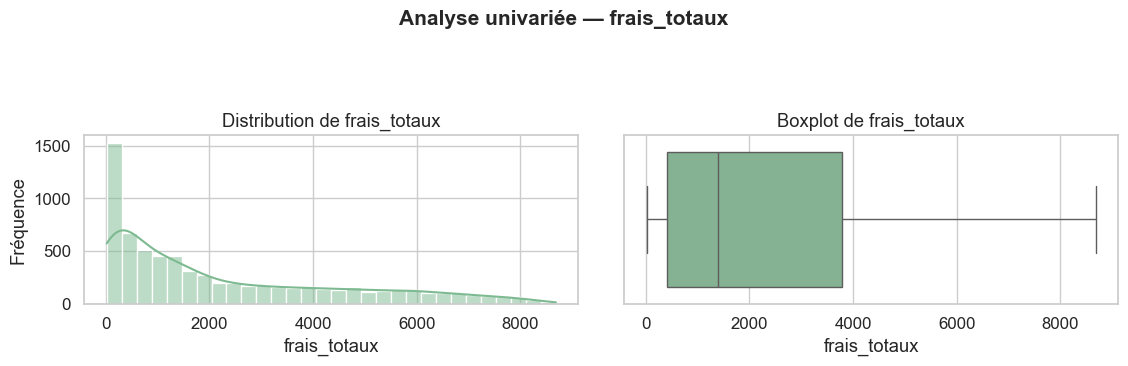

In [33]:
analyse_quantitative(data, col_num)

🔹 Variable : anciennete_mois

La moyenne est de 32,37 mois, et la médiane de 29 mois.
Ces deux valeurs sont proches, ce qui indique une légère asymétrie à droite.
Cela signifie que la majorité des clients ont une ancienneté inférieure à 30 mois, mais qu’un petit groupe de clients anciens tire la moyenne vers le haut.

L’écart-type est de 24,56, presque égal aux trois quarts de la moyenne (CV ≈ 0,76), ce qui traduit une grande dispersion : les clients n’ont pas tous la même durée d’ancienneté.
Les valeurs s’étendent de 0 à 72 mois, ce qui correspond à des clients allant de tout nouveaux à environ 6 ans de fidélité.

Les coefficients d’asymétrie (0,24) et d’aplatissement (-1,39) confirment une distribution légèrement asymétrique et aplatie, donc peu concentrée autour d’une valeur unique.

En résumé : l’ancienneté des clients est très variée, sans valeurs aberrantes, et couvre tout le cycle de vie client.

🔹 Variable : frais_mensuels

La moyenne est de 64,76 €, et la médiane de 70,35 €.
La moyenne étant légèrement inférieure à la médiane, la distribution présente une asymétrie légère à gauche, ce qui indique qu’un petit nombre de clients paient des montants mensuels plus faibles.

L’écart-type est de 30,09, soit un CV ≈ 0,46, révélant une dispersion modérée : les clients dépensent des montants variés, mais sans différences extrêmes.
Les valeurs vont de 18,25 € à 118,75 €, ce qui montre une gamme de forfaits diversifiée.

L’asymétrie (-0,22) et le kurtosis (-1,26) confirment une distribution aplatie et presque symétrique, sans pic prononcé.
Aucun outlier n’est visible sur le boxplot, ce qui indique une répartition homogène.

En résumé : les frais mensuels sont bien répartis entre les clients, sans valeurs anormales, et reflètent probablement la diversité des offres souscrites.

🔹 Variable : frais_totaux

La moyenne est de 2283,30 €, et la médiane de 1397,47 €.
La moyenne est nettement supérieure à la médiane, ce qui traduit une forte asymétrie à droite : quelques clients cumulent des montants beaucoup plus élevés que la majorité.

L’écart-type est de 2266,77, presque égal à la moyenne (CV ≈ 0,99), ce qui révèle une dispersion très importante.
Les valeurs s’étendent de 18,80 € à 8684,80 €, soit un écart très large entre les plus petits et les plus gros montants.

Les coefficients d’asymétrie (0,96) et d’aplatissement (-0,20) montrent une distribution étalée et asymétrique, avec une queue longue vers les grandes valeurs.
Aucune valeur ne dépasse les bornes définies par la règle des 1,5 × IQR, mais la distribution reste très dispersée.

En résumé : les frais totaux varient fortement d’un client à l’autre, en fonction de leur ancienneté et de leur profil.

In [35]:
##Affichons les lignes dont l'ancienneté est égale à 0
data[data['anciennete_mois'] == 0].sample(5)

,sexe,senior,en_couple,ayant_personnes_a_charge,anciennete_mois,service_telephone,lignes_multiples,type_internet,securite_en_ligne,sauvegarde_en_ligne,protection_appareils,support_technique,tv_en_streaming,films_en_streaming,type_contrat,facturation_numerique,methode_paiement,frais_mensuels,frais_totaux,resiliation
488,Female,non_senior,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
936,Female,non_senior,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,non_senior,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,non_senior,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
753,Male,non_senior,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No


In [36]:
data.isna().sum()

sexe                         0
senior                       0
en_couple                    0
ayant_personnes_a_charge     0
anciennete_mois              0
service_telephone            0
lignes_multiples             0
type_internet                0
securite_en_ligne            0
sauvegarde_en_ligne          0
protection_appareils         0
support_technique            0
tv_en_streaming              0
films_en_streaming           0
type_contrat                 0
facturation_numerique        0
methode_paiement             0
frais_mensuels               0
frais_totaux                11
resiliation                  0
dtype: int64

In [37]:
data.isna().mean()

sexe                        0.000000
senior                      0.000000
en_couple                   0.000000
ayant_personnes_a_charge    0.000000
anciennete_mois             0.000000
service_telephone           0.000000
lignes_multiples            0.000000
type_internet               0.000000
securite_en_ligne           0.000000
sauvegarde_en_ligne         0.000000
protection_appareils        0.000000
support_technique           0.000000
tv_en_streaming             0.000000
films_en_streaming          0.000000
type_contrat                0.000000
facturation_numerique       0.000000
methode_paiement            0.000000
frais_mensuels              0.000000
frais_totaux                0.001562
resiliation                 0.000000
dtype: float64

In [38]:
##verifions les lignes avec des valeurs manquantes dans frais_totaux
data[data['frais_totaux'].isna()]

,sexe,senior,en_couple,ayant_personnes_a_charge,anciennete_mois,service_telephone,lignes_multiples,type_internet,securite_en_ligne,sauvegarde_en_ligne,protection_appareils,support_technique,tv_en_streaming,films_en_streaming,type_contrat,facturation_numerique,methode_paiement,frais_mensuels,frais_totaux,resiliation
488,Female,non_senior,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,non_senior,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,non_senior,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,non_senior,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,non_senior,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,non_senior,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,non_senior,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,non_senior,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,non_senior,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,non_senior,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [48]:
###affichon les lignes ou on a les non senior avec ancienneté égale à 0,dont les frais_totaux sont pas manquants
data[(data['anciennete_mois'] == 0) & (data['senior'] == 'non_senior') & (data['frais_totaux'].notna())].head(5)


,sexe,senior,en_couple,ayant_personnes_a_charge,anciennete_mois,service_telephone,lignes_multiples,type_internet,securite_en_ligne,sauvegarde_en_ligne,protection_appareils,support_technique,tv_en_streaming,films_en_streaming,type_contrat,facturation_numerique,methode_paiement,frais_mensuels,frais_totaux,resiliation


In [50]:
##affichons les nombres des lignes ou on a les non senior avec ancienneté égale à 0
data[(data['anciennete_mois'] == 0)].shape[0]

11

In [51]:
###Nous remarqu'on que les lignes avec ancienneté égale à 0 correspondent aux nouveaux clients qui n'ont pas encore été facturés, ce qui explique pourquoi leurs frais totaux sont manquants.d'ou on remplacera les valeurs manquantes par 0 dans la colonne frais_totaux.
data['frais_totaux'] = data['frais_totaux'].fillna(0)

In [55]:
###Analyse univarié variable catégorielle
def analyse_qualitatives(df, cols):
    """
    Analyse univariée des variables qualitatives :
    - Tableau de fréquences absolues et relatives
    - Diagramme en barres
    - Gestion des valeurs manquantes
    """

    for col in cols:
        print(f"\n ===> Variable : {col}")
        print("=" * (14 + len(col)))

        # Table de fréquences
        freq = df[col].value_counts(dropna=False)
        perc = round(df[col].value_counts(normalize=True, dropna=False) * 100, 2)
        summary = pd.DataFrame({"Effectif": freq, "Pourcentage (%)": perc})
        display(summary.style.background_gradient(cmap="Purples").format(precision=2))

        # Visualisation
        plt.figure(figsize=(7,4))
        sns.countplot(x=col, data=df, palette="Purples_r", order=freq.index)
        plt.title(f"Répartition des modalités de '{col}'", fontsize=13, fontweight='bold')
        plt.xlabel("")
        plt.ylabel("Nombre d'observations")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


 ===> Variable : sexe


,Effectif,Pourcentage (%)
sexe,,
Male,3555,50.48
Female,3488,49.52


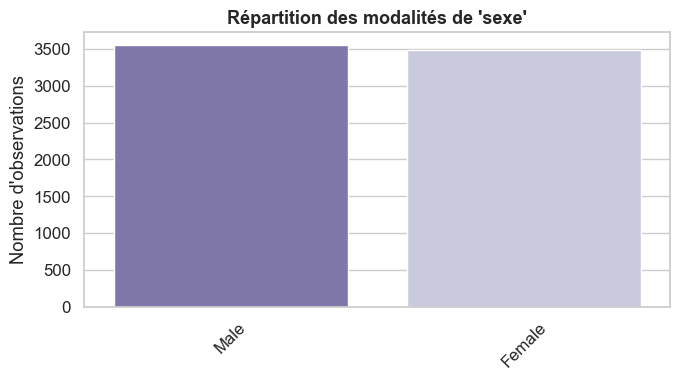


 ===> Variable : senior


,Effectif,Pourcentage (%)
senior,,
non_senior,5901,83.79
senior,1142,16.21


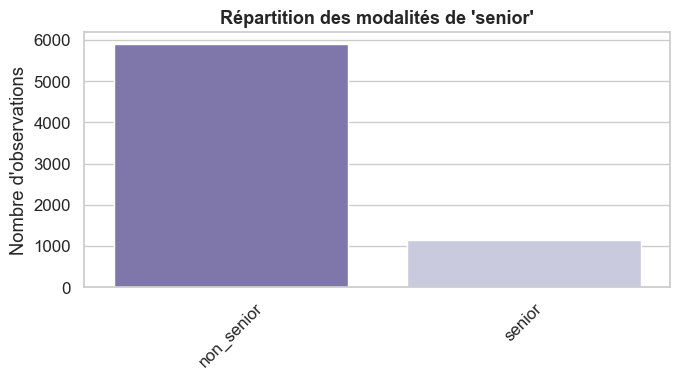


 ===> Variable : en_couple


,Effectif,Pourcentage (%)
en_couple,,
No,3641,51.70
Yes,3402,48.30


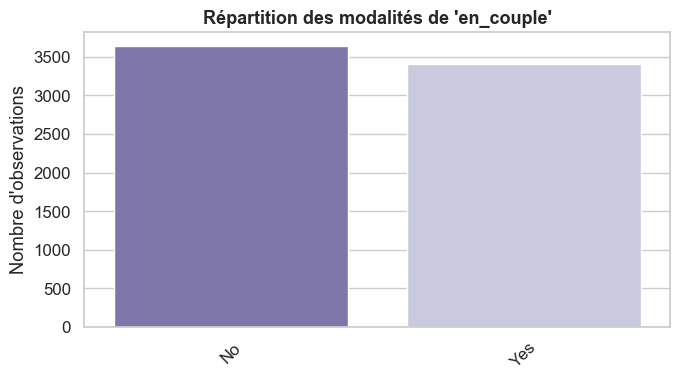


 ===> Variable : ayant_personnes_a_charge


,Effectif,Pourcentage (%)
ayant_personnes_a_charge,,
No,4933,70.04
Yes,2110,29.96


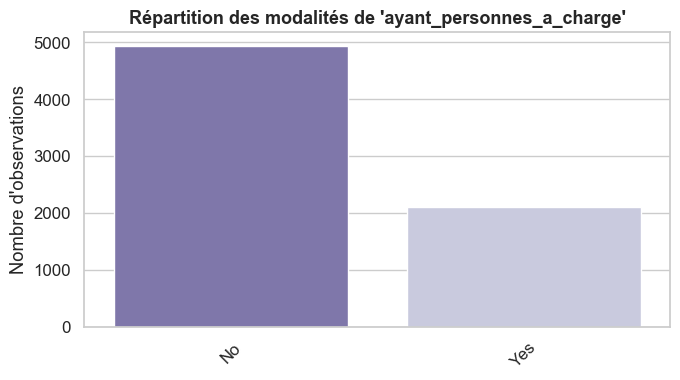


 ===> Variable : service_telephone


,Effectif,Pourcentage (%)
service_telephone,,
Yes,6361,90.32
No,682,9.68


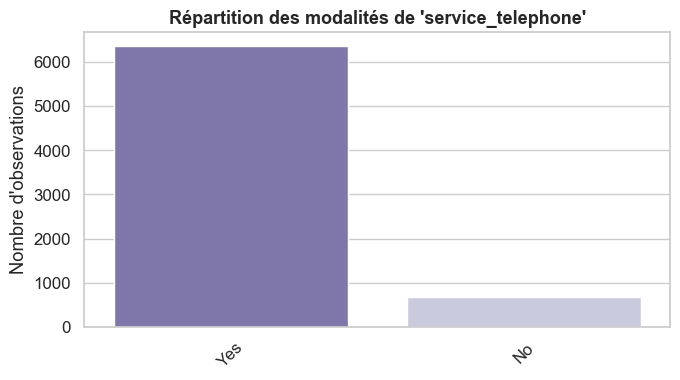


 ===> Variable : lignes_multiples


,Effectif,Pourcentage (%)
lignes_multiples,,
No,3390,48.13
Yes,2971,42.18
No phone service,682,9.68


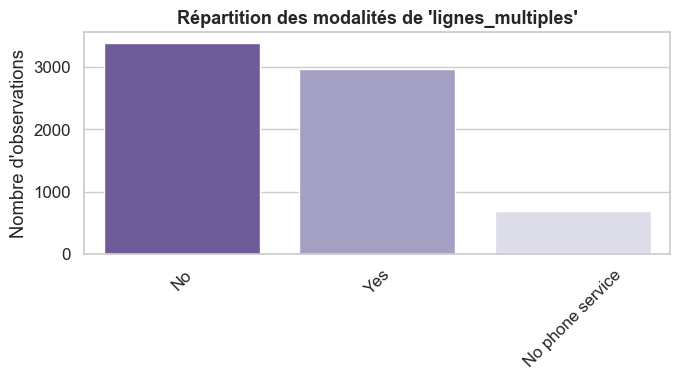


 ===> Variable : type_internet


,Effectif,Pourcentage (%)
type_internet,,
Fiber optic,3096,43.96
DSL,2421,34.37
No,1526,21.67


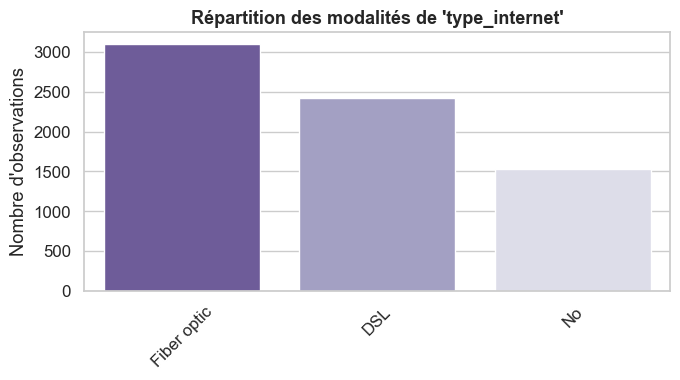


 ===> Variable : securite_en_ligne


,Effectif,Pourcentage (%)
securite_en_ligne,,
No,3498,49.67
Yes,2019,28.67
No internet service,1526,21.67


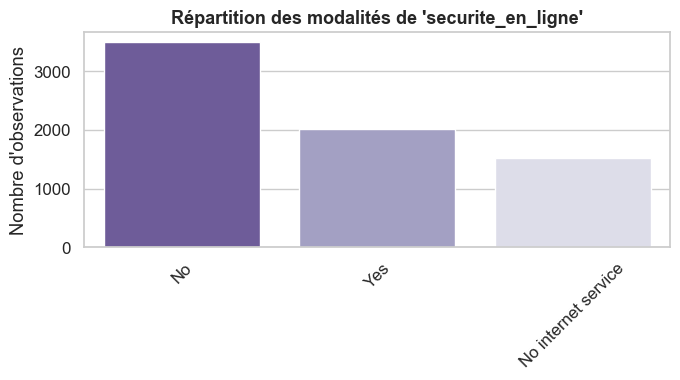


 ===> Variable : sauvegarde_en_ligne


,Effectif,Pourcentage (%)
sauvegarde_en_ligne,,
No,3088,43.84
Yes,2429,34.49
No internet service,1526,21.67


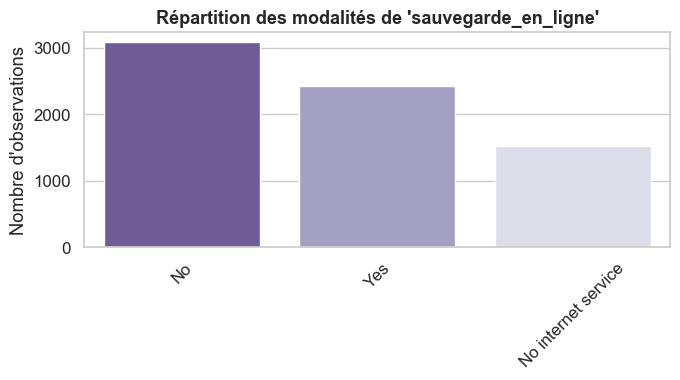


 ===> Variable : protection_appareils


,Effectif,Pourcentage (%)
protection_appareils,,
No,3095,43.94
Yes,2422,34.39
No internet service,1526,21.67


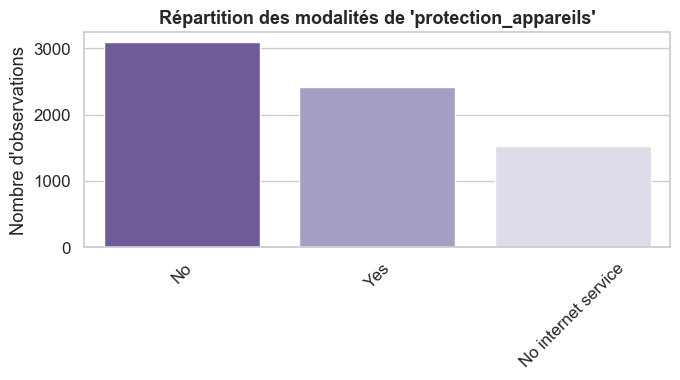


 ===> Variable : support_technique


,Effectif,Pourcentage (%)
support_technique,,
No,3473,49.31
Yes,2044,29.02
No internet service,1526,21.67


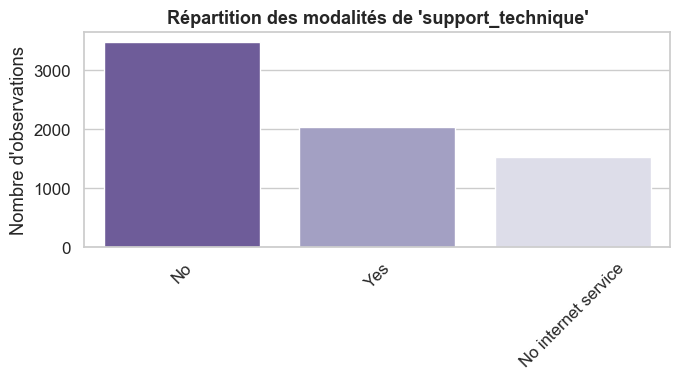


 ===> Variable : tv_en_streaming


,Effectif,Pourcentage (%)
tv_en_streaming,,
No,2810,39.90
Yes,2707,38.44
No internet service,1526,21.67


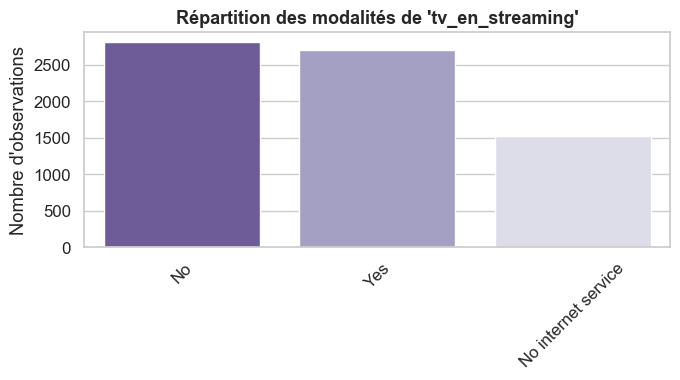


 ===> Variable : films_en_streaming


,Effectif,Pourcentage (%)
films_en_streaming,,
No,2785,39.54
Yes,2732,38.79
No internet service,1526,21.67


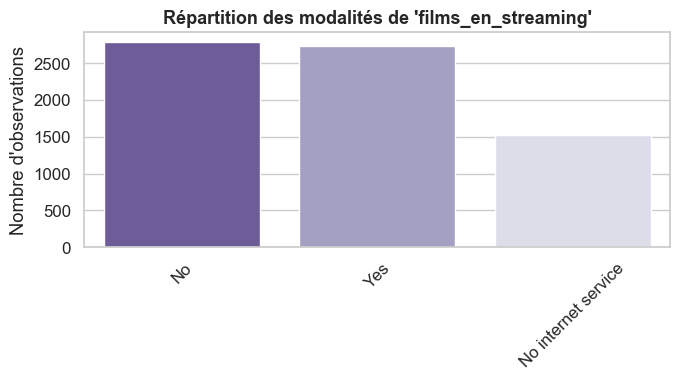


 ===> Variable : type_contrat


,Effectif,Pourcentage (%)
type_contrat,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91


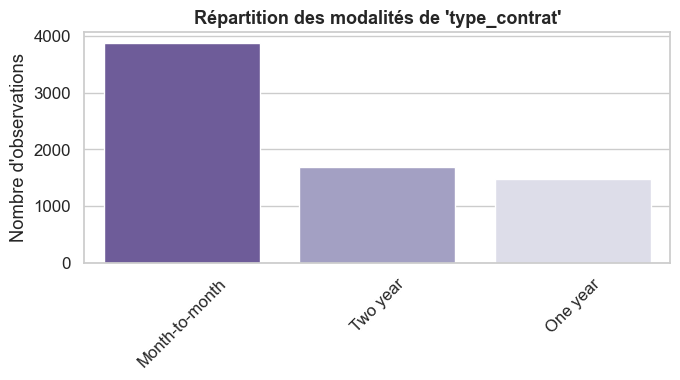


 ===> Variable : facturation_numerique


,Effectif,Pourcentage (%)
facturation_numerique,,
Yes,4171,59.22
No,2872,40.78


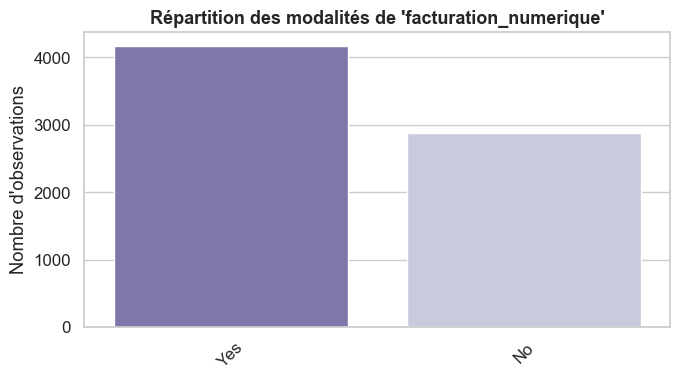


 ===> Variable : methode_paiement


,Effectif,Pourcentage (%)
methode_paiement,,
Electronic check,2365,33.58
Mailed check,1612,22.89
Bank transfer (automatic),1544,21.92
Credit card (automatic),1522,21.61


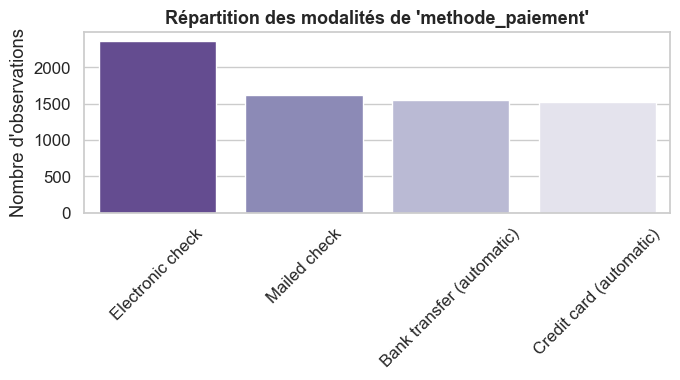


 ===> Variable : resiliation


,Effectif,Pourcentage (%)
resiliation,,
No,5174,73.46
Yes,1869,26.54


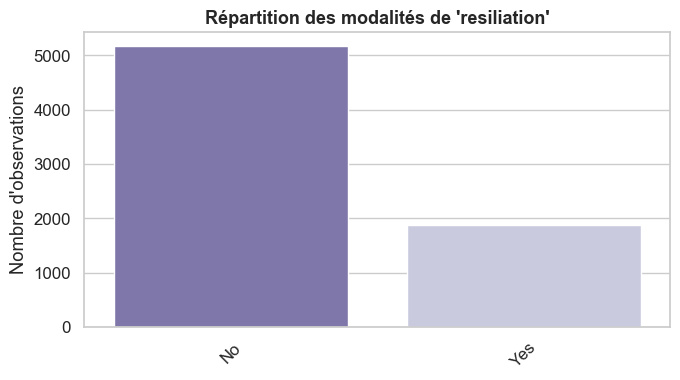

In [56]:
analyse_qualitatives(data, col_cat)

In [58]:
##Remplaçons les modalités 'No internet service' par 'No' dans les colonnes liées aux services Internet,et 'No phone service' par 'No' dans les colonnes liées aux services téléphoniques.
data.replace('No internet service', 'No', inplace=True)
data.replace('No phone service', 'No', inplace=True)

L’échantillon présente une répartition équilibrée entre les hommes et les femmes, ce qui garantit l’absence de biais de genre.
La majorité des clients sont non-seniors, indiquant une clientèle plutôt jeune.
On observe également qu’une grande partie des clients n’a pas de personnes à charge, traduisant un profil familial léger.

Concernant les services, la quasi-totalité des clients dispose d’un service téléphonique, rendant cette variable peu discriminante.
En revanche, la répartition des types de contrat montre que plus de la moitié des clients sont engagés au mois, suggérant une certaine flexibilité mais aussi un risque de résiliation plus élevé.

Enfin, la variable résiliation est déséquilibrée : environ 73 % des clients n’ont pas résilié contre 27 % ayant quitté le service, ce qui met en évidence un déséquilibre de classes à considérer lors de la modélisation.

### Analyse bivariée

identifier les relations et interactions significatives entre les variables explicatives (qualitatives et quantitatives) et la variable cible (resiliation), afin de comprendre les facteurs influençant la résiliation des clients.

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.1)

def _barlabel_percent(ax):
    """Étiquette le % à l'intérieur des barres (fallback si bar_label indisponible)."""
    try:
        for c in ax.containers:
            ax.bar_label(c, fmt="%.1f%%", label_type="center", fontsize=10, color="black")
    except Exception:
        for p in ax.patches:
            h = p.get_height()
            ax.annotate(f"{h:.1f}%",
                        (p.get_x() + p.get_width()/2., h/2),
                        ha="center", va="center", fontsize=10, color="black")

def plot_target_rate_by_category(df, cat_cols, target, positive="Yes"):
    """
    Pour chaque variable catégorielle 'col':
      -> barplot du taux de cible (modalité 'positive') par catégorie de 'col'
      -> étiquettes en % dans les barres
    Aucun tableau, aucune répartition des modalités, aucun test statistique.
    """
    for col in cat_cols:
        taux = (df.groupby(col)[target]
                  .apply(lambda s: (s == positive).mean() * 100)
                  .reset_index())
        taux.columns = [col, f"Taux_{positive}_pct"]
        taux = taux.sort_values(f"Taux_{positive}_pct", ascending=False)

        plt.figure(figsize=(8,4))
        ax = sns.barplot(
            data=taux,
            x=col, y=f"Taux_{positive}_pct",
            order=taux[col],
            palette="crest"
        )
        _barlabel_percent(ax)
        plt.title(f"Taux de {target} = {positive} par '{col}'", fontsize=13, fontweight="bold")
        plt.xlabel("")
        plt.ylabel(f"Taux {positive} (%)")
        plt.ylim(0, 100)
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()




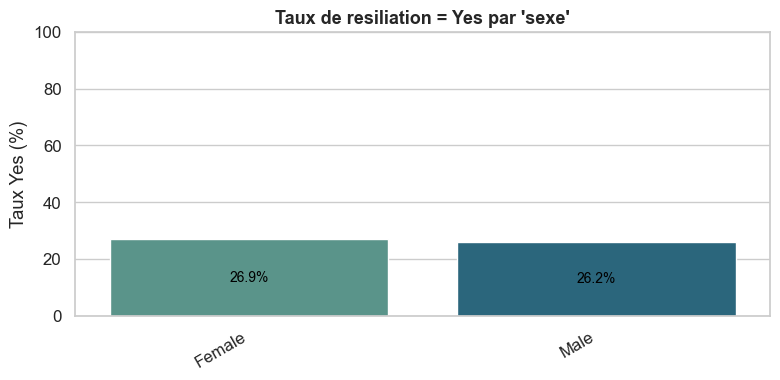

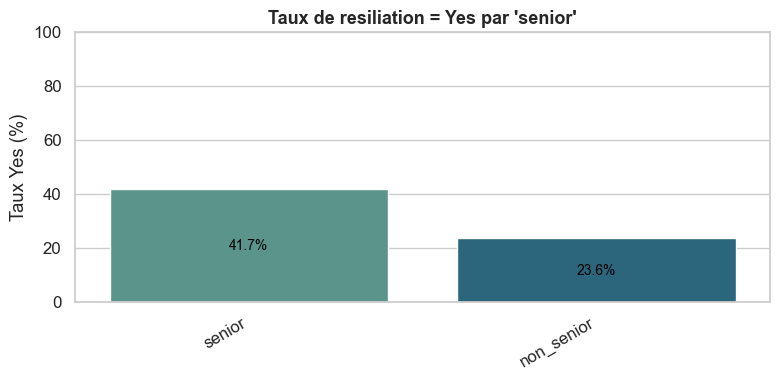

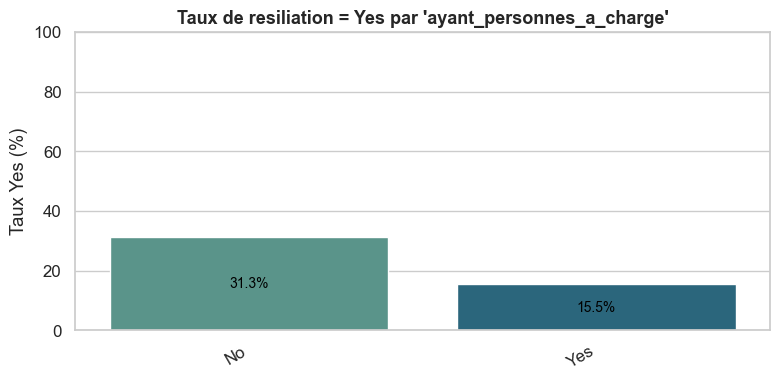

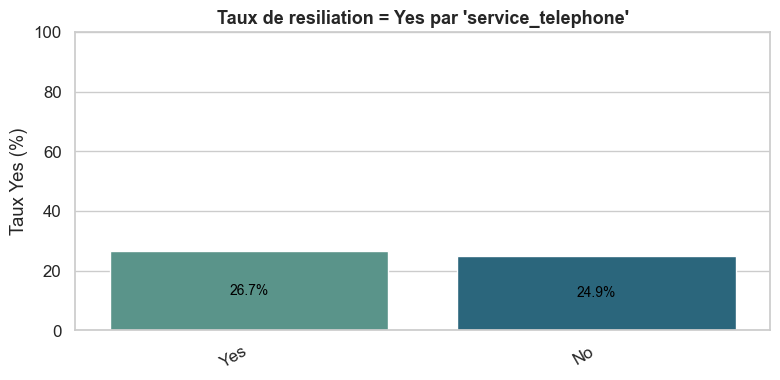

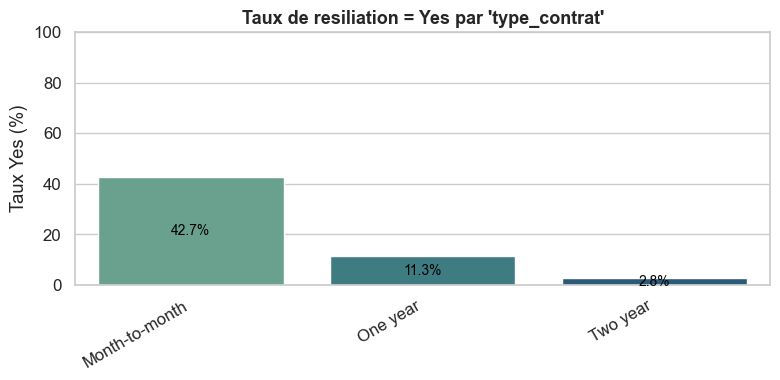

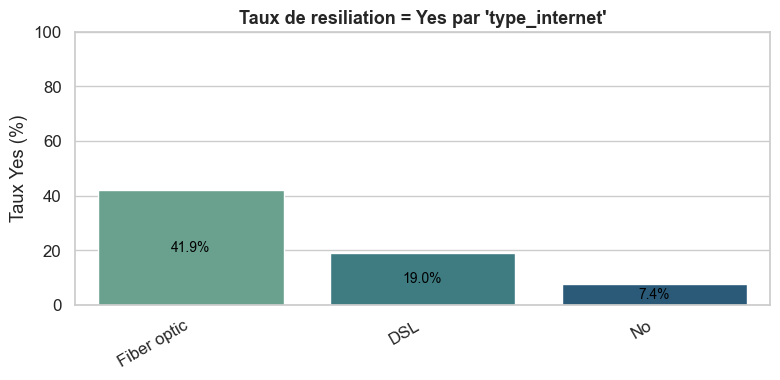

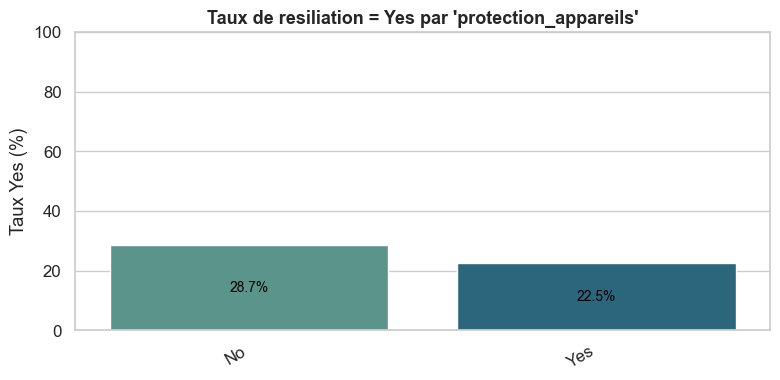

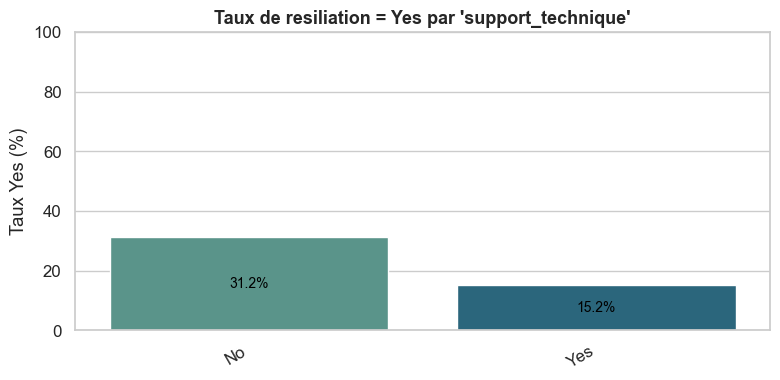

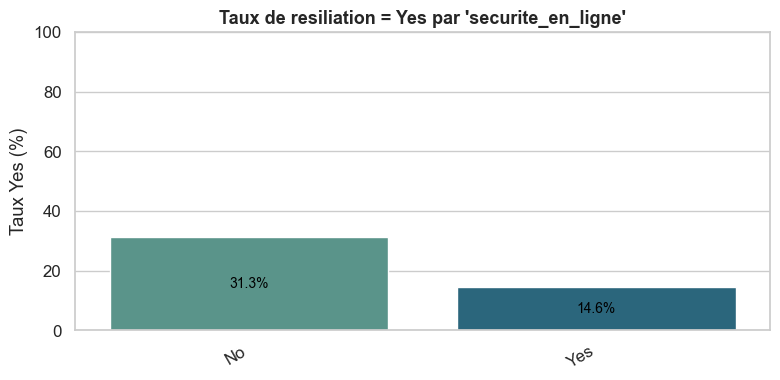

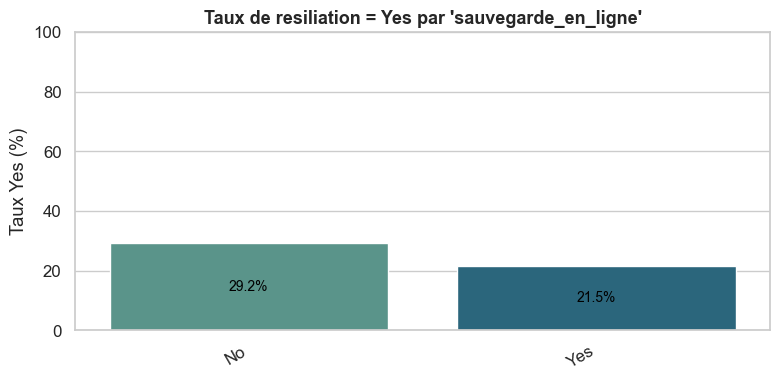

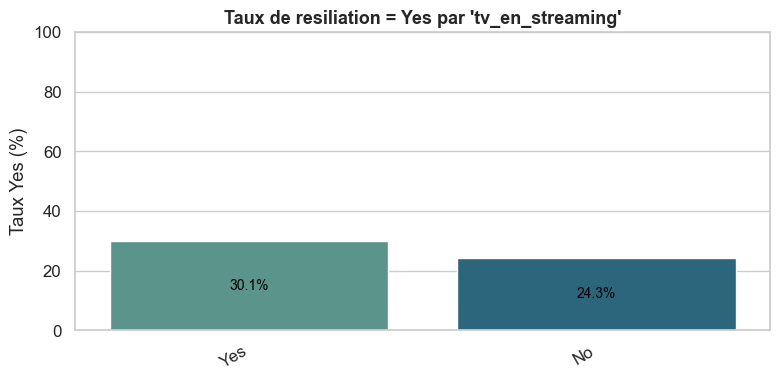

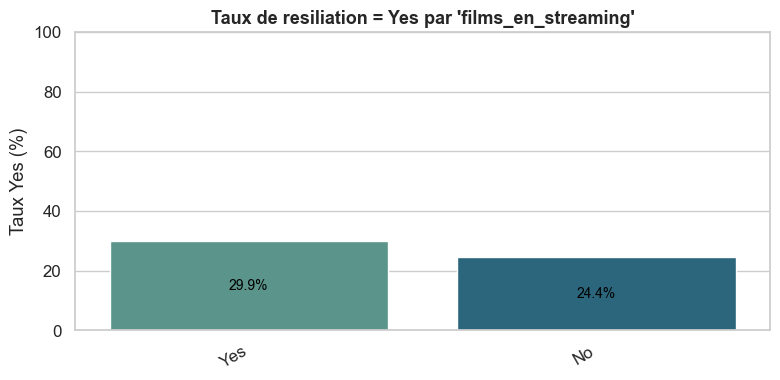

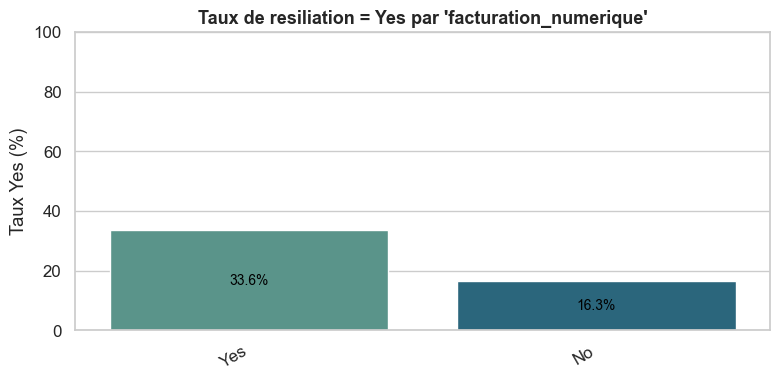

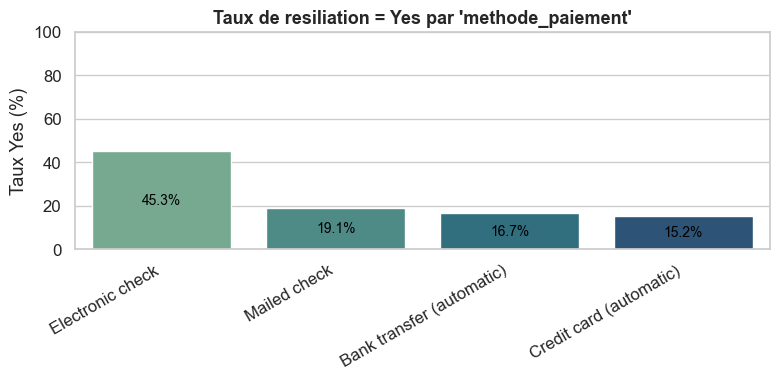

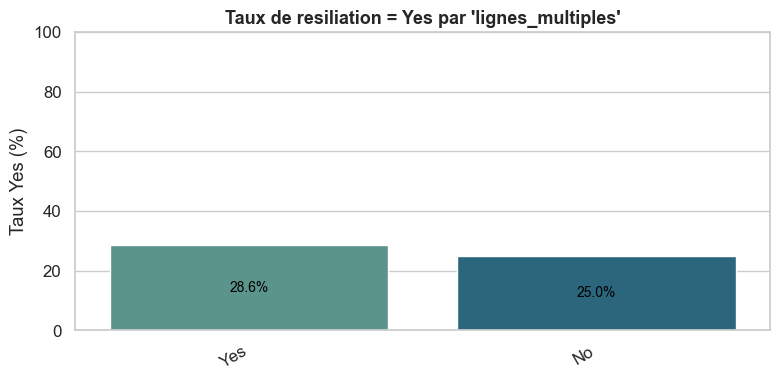

In [77]:
cat_colonne = [
    "sexe", "senior", "ayant_personnes_a_charge",
    "service_telephone", "type_contrat", "type_internet",
    "protection_appareils", "support_technique", "securite_en_ligne",
    "sauvegarde_en_ligne", "tv_en_streaming", "films_en_streaming",
    "facturation_numerique", "methode_paiement", "lignes_multiples"
]

plot_target_rate_by_category(data, cat_colonne, target="resiliation", positive="Yes")


In [78]:
import pandas as pd
from scipy.stats import chi2_contingency
from IPython.display import display

def test_chi2_categoricals(df, cat_cols, target):
    """
    Effectue un test du Khi² entre chaque variable catégorielle et la variable cible.
    Affiche un tableau récapitulatif clair avec les résultats et la significativité.
    """
    results = []

    for col in cat_cols:
        ct = pd.crosstab(df[col], df[target])
        chi2, p, dof, expected = chi2_contingency(ct)
        results.append({
            "Variable": col,
            "Chi²": round(chi2, 3),
            "ddl": dof,
            "p-value": round(p, 4),
            "Conclusion": " Significatif (p < 0.05)" if p < 0.05 else " Non significatif"
        })

    result_df = pd.DataFrame(results).sort_values("p-value")
    print("\n Résultats du test Khi² entre les variables catégorielles et la cible :")
    display(result_df.style.background_gradient(cmap="Purples").format(precision=3))
    return result_df


In [79]:
cat_colonne = [
    "sexe", "senior", "ayant_personnes_a_charge",
    "service_telephone", "type_contrat", "type_internet",
    "protection_appareils", "support_technique", "securite_en_ligne",
    "sauvegarde_en_ligne", "tv_en_streaming", "films_en_streaming",
    "facturation_numerique", "methode_paiement", "lignes_multiples"
]

results_chi2 = test_chi2_categoricals(data, cat_colonne, target="resiliation")



 Résultats du test Khi² entre les variables catégorielles et la cible :


,Variable,Chi²,ddl,p-value,Conclusion
1,senior,159.426,1,0.000,Significatif (p < 0.05)
2,ayant_personnes_a_charge,189.129,1,0.000,Significatif (p < 0.05)
4,type_contrat,1184.597,2,0.000,Significatif (p < 0.05)
5,type_internet,732.310,2,0.000,Significatif (p < 0.05)
6,protection_appareils,30.513,1,0.000,Significatif (p < 0.05)
7,support_technique,190.167,1,0.000,Significatif (p < 0.05)
8,securite_en_ligne,205.633,1,0.000,Significatif (p < 0.05)
9,sauvegarde_en_ligne,47.261,1,0.000,Significatif (p < 0.05)
10,tv_en_streaming,27.863,1,0.000,Significatif (p < 0.05)
11,films_en_streaming,26.251,1,0.000,Significatif (p < 0.05)


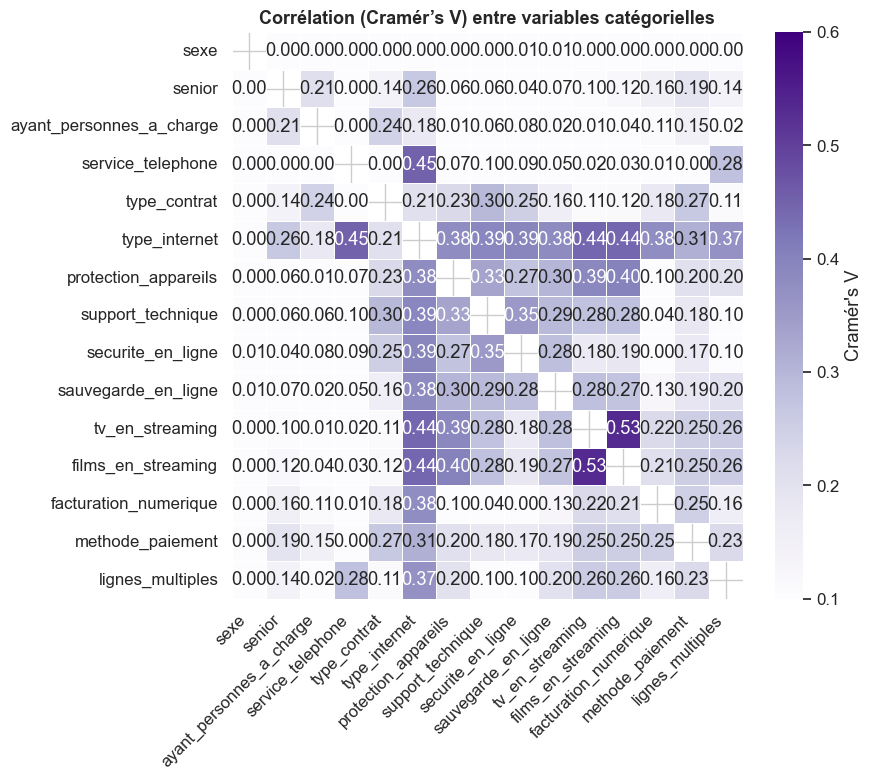

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,8))
sns.heatmap(cramer_matrix.astype(float),
            annot=True,
            fmt=".2f",
            cmap="Purples",       # palette douce et contrastée
            vmin=0.1, vmax=0.6,   # resserre l’échelle pour mieux voir les différences
            linewidths=0.5,
            cbar_kws={'label': "Cramér's V"})
plt.title("Corrélation (Cramér’s V) entre variables catégorielles", fontsize=13, fontweight='bold')
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In [83]:
###creons une variable binaire service_streaming qui indique si un client utilise au moins un service de streaming (TV ou films),ou non.
data['service_streaming'] = ((data['tv_en_streaming'] == 'Yes') | (data['films_en_streaming'] == 'Yes')).map({True: 'Yes', False: 'No'})

In [97]:
###verifions la création de la nouvelle variable
data[['tv_en_streaming', 'films_en_streaming', 'service_streaming']].sample(10)

,tv_en_streaming,films_en_streaming,service_streaming
2376,Yes,No,Yes
2860,Yes,Yes,Yes
1231,No,Yes,Yes
3446,Yes,Yes,Yes
4548,No,Yes,Yes
4631,Yes,No,Yes
1953,No,No,No
7015,Yes,No,Yes
2662,Yes,Yes,Yes
1608,No,No,No


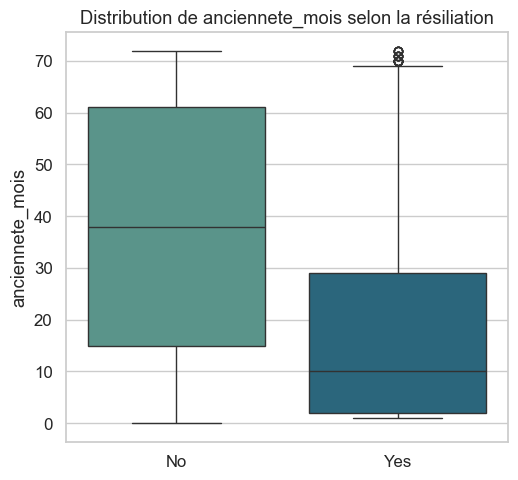

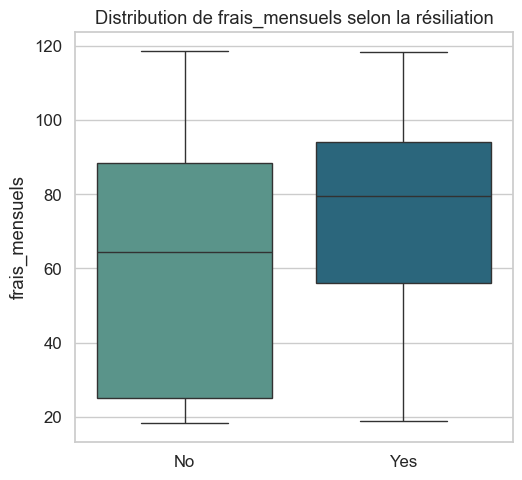

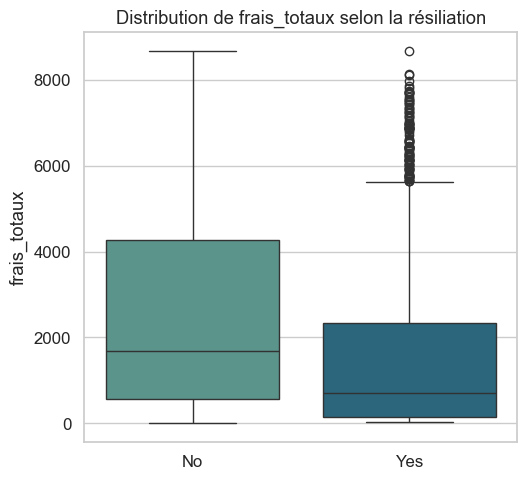

=== Test de Student (t-test) ===
anciennete_mois: p-value = 0.00000 → significatif
frais_mensuels: p-value = 0.00000 → significatif
frais_totaux: p-value = 0.00000 → significatif


In [99]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

quant_vars = ["anciennete_mois", "frais_mensuels", "frais_totaux"]
target = "resiliation"

# Style
sns.set(style="whitegrid", palette="crest", font_scale=1.1)

# Création des graphiques côte à côte
for col in quant_vars:
    plt.figure(figsize=(10, 5))
    
    #  Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(x=target, y=col, data=data, palette="crest")
    plt.title(f"Distribution de {col} selon la résiliation")
    plt.xlabel("")
    plt.ylabel(col) 
    
    plt.tight_layout()
    plt.show()

#  Test de comparaison de moyennes
print("=== Test de Student (t-test) ===")
for col in quant_vars:
    yes = data[data[target] == "Yes"][col]
    no = data[data[target] == "No"][col]
    stat, pval = ttest_ind(yes, no, equal_var=False)
    print(f"{col}: p-value = {pval:.5f} {'→ significatif' if pval < 0.05 else '→ non significatif'}")


Les clients récents, ayant des factures mensuelles plus élevées, sont ceux qui résilient le plus tôt.
En revanche, les clients plus anciens et aux frais stables ont tendance à rester fidèles.
Cela oriente les actions marketing vers :

- la rétention des nouveaux clients pendant les premiers mois,
- la révision des tarifs élevés, perçus comme une cause potentielle de départ,
- et le suivi des clients premium (fibre optique) plus exposés au churn.

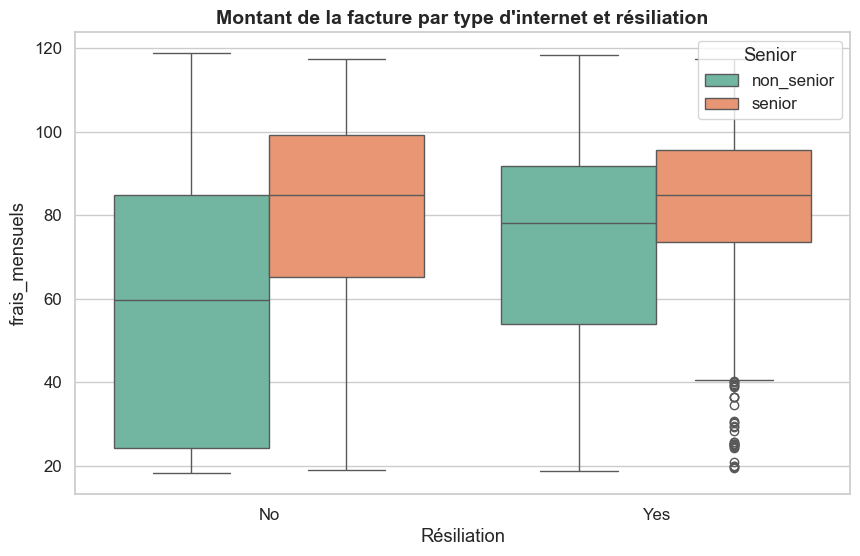

In [104]:
##Fiason un liée si les clients qui se desabonne ou pas avec une facture mensuelle élevée en fonction de leur type d'internet
plt.figure(figsize=(10, 6))
sns.boxplot(x="resiliation", y="frais_mensuels", hue="senior", data=data, palette="Set2")
plt.title("Montant de la facture par type d'internet et résiliation", fontsize=14, fontweight='bold')
plt.xlabel("Résiliation")
plt.ylabel("frais_mensuels")
plt.legend(title="Senior", loc="upper right")
plt.show()


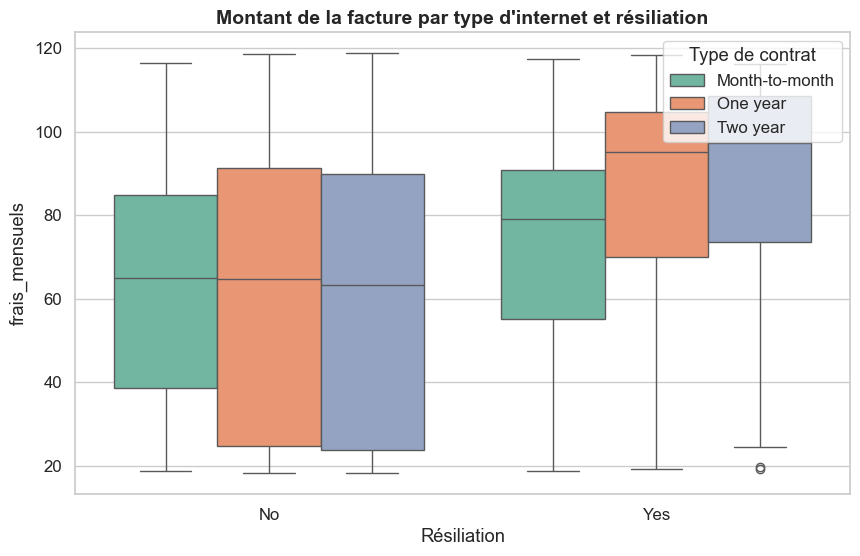

In [105]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="resiliation", y="frais_mensuels", hue="type_contrat", data=data, palette="Set2")
plt.title("Montant de la facture par type d'internet et résiliation", fontsize=14, fontweight='bold')
plt.xlabel("Résiliation")
plt.ylabel("frais_mensuels")
plt.legend(title="Type de contrat", loc="upper right")
plt.show()

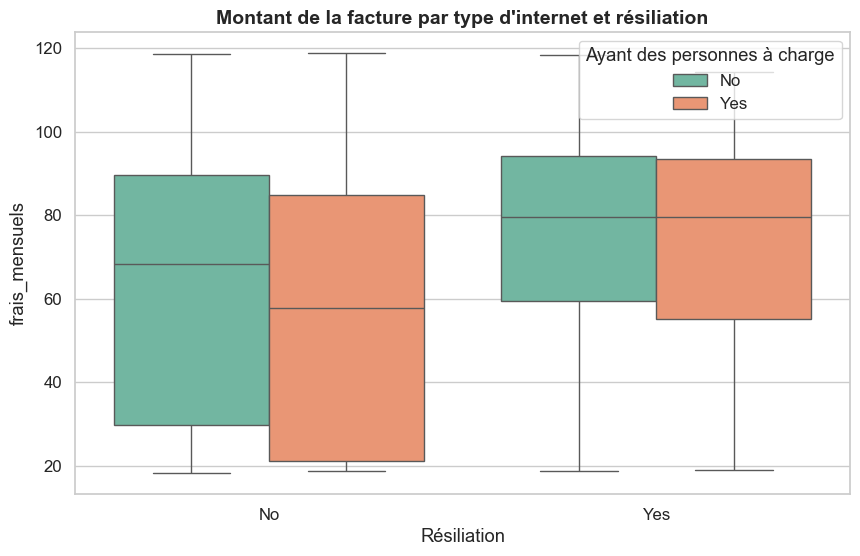

In [107]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="resiliation", y="frais_mensuels", hue="ayant_personnes_a_charge", data=data, palette="Set2")
plt.title("Montant de la facture par type d'internet et résiliation", fontsize=14, fontweight='bold')
plt.xlabel("Résiliation")
plt.ylabel("frais_mensuels")
plt.legend(title="Ayant des personnes à charge", loc="upper right")
plt.show()

Ces analyses confirment que le montant de la facture mensuelle influence fortement la résiliation,
mais son effet dépend des caractéristiques clients :

- Les contrats courts → clients volatils.
- Les seniors → sensibles au prix élevé.
- Les familles → plus stables et fidèles.

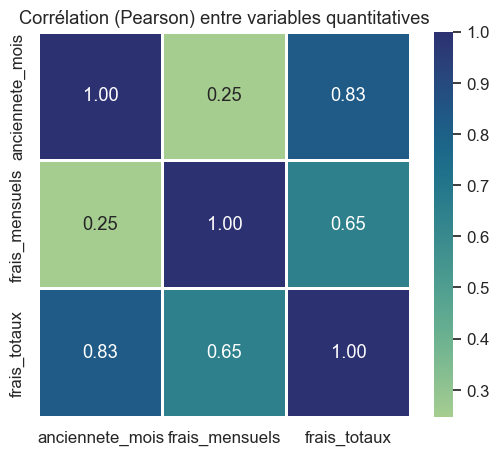

=== Interprétation des corrélations ===
frais_mensuels ↔ anciennete_mois : 0.25 → Corrélation faible
frais_totaux ↔ anciennete_mois : 0.83 → ⚠️ Très forte corrélation
frais_totaux ↔ frais_mensuels : 0.65 → Forte corrélation


In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables quantitatives
quant_vars = ["anciennete_mois", "frais_mensuels", "frais_totaux"]

# Matrice de corrélation
corr = data[quant_vars].corr(method="pearson")

# Affichage
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="crest", fmt=".2f", linewidths=0.8)
plt.title("Corrélation (Pearson) entre variables quantitatives")
plt.show()

# Interprétation rapide
print("=== Interprétation des corrélations ===")
for i in range(len(corr.columns)):
    for j in range(i):
        coef = corr.iloc[i,j]
        v1, v2 = corr.columns[i], corr.columns[j]
        if abs(coef) >= 0.8:
            niveau = "⚠️ Très forte corrélation"
        elif abs(coef) >= 0.6:
            niveau = "Forte corrélation"
        elif abs(coef) >= 0.4:
            niveau = "Corrélation modérée"
        elif abs(coef) >= 0.2:
            niveau = "Corrélation faible"
        else:
            niveau = "Aucune corrélation"
        print(f"{v1} ↔ {v2} : {coef:.2f} → {niveau}")


- La variable frais_totaux dépend directement de l’ancienneté, donc ces deux variables ne doivent pas être utilisées simultanément dans un modèle explicatif.
- En revanche, frais_mensuels et anciennete_mois peuvent être combinés sans risque de redondance.
- Il n’existe aucune multicolinéarité majeure autre que celle attendue entre frais_totaux et anciennete_mois.